In [ ]:
# 0 - data expolration
# The purpose of this notebook is to determine the distribution of the training and
# test data

In [1]:
import sys
import os
sys.path.append(os.path.abspath("."))

from src.data import load_images_from_metadata, filter_images
from src.build_metadata import load_metadata
from src.model import train_and_evaluate, export_onnx
from src.evaluation import evaluate_model, predict_from_image_path


# Step 1: Build metadata.csv from images in the local data folders.
# If you are using the original shared dataset, copy the folders
# (data, data_new, data_new_2, data_test) into this project root first.
load_metadata(
    data_base_dir="data",
    new_data_base_dir="data_new",
    new_data_2_base_dir="data_new_2",
    output_file="metadata.csv",
)

# Step 2: Load images from metadata.csv.
# crop_fraction=0.4 keeps the center region by trimming edges before training.
data = load_images_from_metadata("metadata.csv", crop_fraction=0.4, use_cv2=True)

# Step 3: Filter the dataset used for training/evaluation.
# Standards are currently limited to specific collection dates due to
# known collection issues; adjust these filters if your dataset is different.
data_standards = filter_images(
    data,
    ImageType="STD",
    State="flat",
    DateCollected=["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"],
)
data_real_paint = filter_images(data, ImageType="DD", State="flat")

Applied human ratings to 851 DD rows.
Saved metadata to .\metadata.csv
Combined records: 1337
Loaded 1337 images (cropping=ON, median_norm=OFF, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


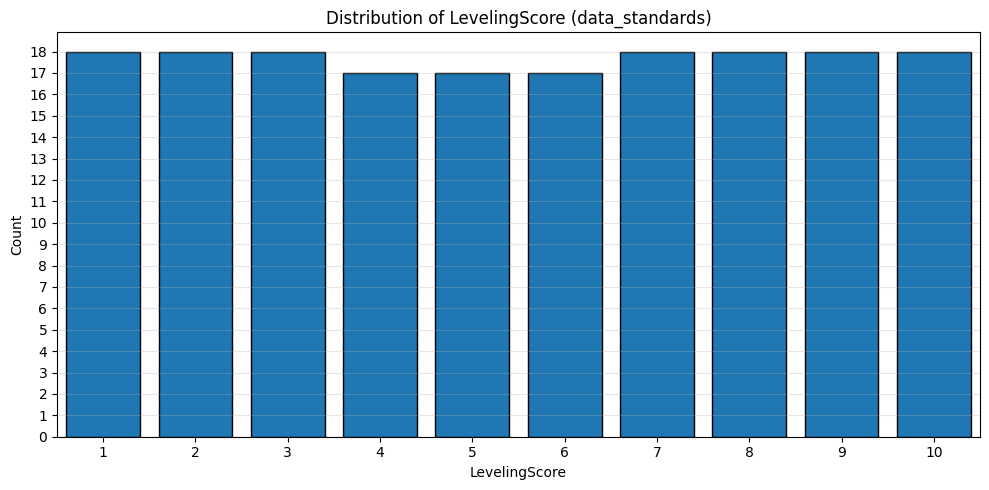

In [2]:
# print out the distribution of LevelingScore values for data_standards as a histogram
import matplotlib.pyplot as plt
from collections import Counter

# Extract numeric LevelingScore values and ignore missing/non-numeric entries.
scores = []
for item in data_standards:
    value = item.get("LevelingScore")
    try:
        scores.append(float(value))
    except (TypeError, ValueError):
        continue

if not scores:
    print("No valid LevelingScore values found in data_standards.")
else:
    # Count each unique score so each bar maps to one label on the x-axis.
    score_counts = Counter(scores)
    x_values = sorted(score_counts.keys())
    y_values = [score_counts[x] for x in x_values]

    plt.figure(figsize=(10, 5))
    plt.bar(x_values, y_values, width=0.8, edgecolor="black")
    plt.title("Distribution of LevelingScore (data_standards)")
    plt.xlabel("LevelingScore")
    plt.ylabel("Count")

    # Force y-axis to show only whole numbers.
    import math
    max_count = max(y_values)
    plt.yticks(range(0, max_count + 1))

    # Force a numeric starting tick so the axis start is explicit.
    if all(float(x).is_integer() for x in x_values):
        start_tick = int(min(x_values))
        end_tick = int(max(x_values))
        tick_values = list(range(start_tick, end_tick + 1))
        plt.xticks(tick_values, [str(t) for t in tick_values])
        plt.xlim(start_tick - 0.5, end_tick + 0.5)
    else:
        x_labels = [str(x) for x in x_values]
        plt.xticks(x_values, x_labels)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


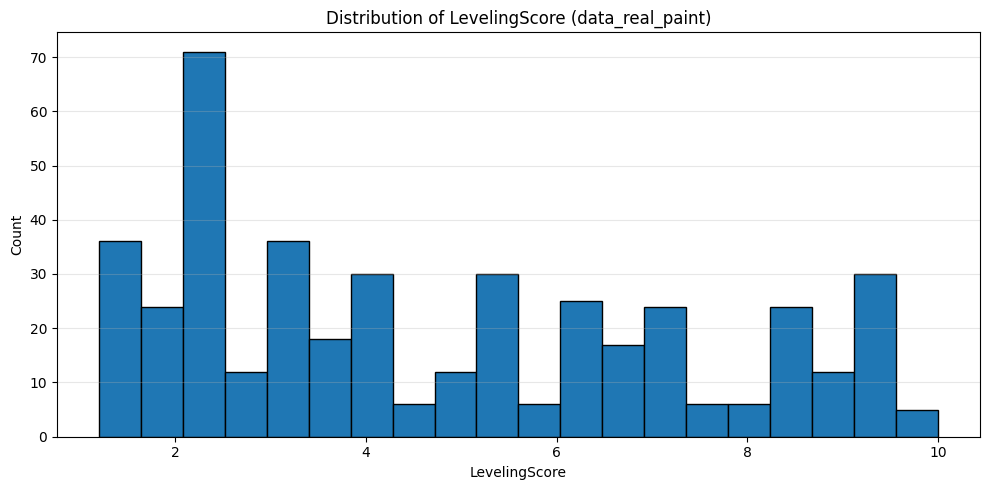

In [9]:
# print out the distribution of LevelingScore values for data_real_paint as a histogram
import matplotlib.pyplot as plt

# Extract numeric LevelingScore values and ignore missing/non-numeric entries.
scores_real_paint = []
for item in data_real_paint:
    value = item.get("LevelingScore")
    try:
        scores_real_paint.append(float(value))
    except (TypeError, ValueError):
        continue

if not scores_real_paint:
    print("No valid LevelingScore values found in data_real_paint.")
else:
    plt.figure(figsize=(10, 5))
    plt.hist(scores_real_paint, bins=20, edgecolor="black")
    plt.title("Distribution of LevelingScore (data_real_paint)")
    plt.xlabel("LevelingScore")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

Using camera: Rob2BDR-9F0Z


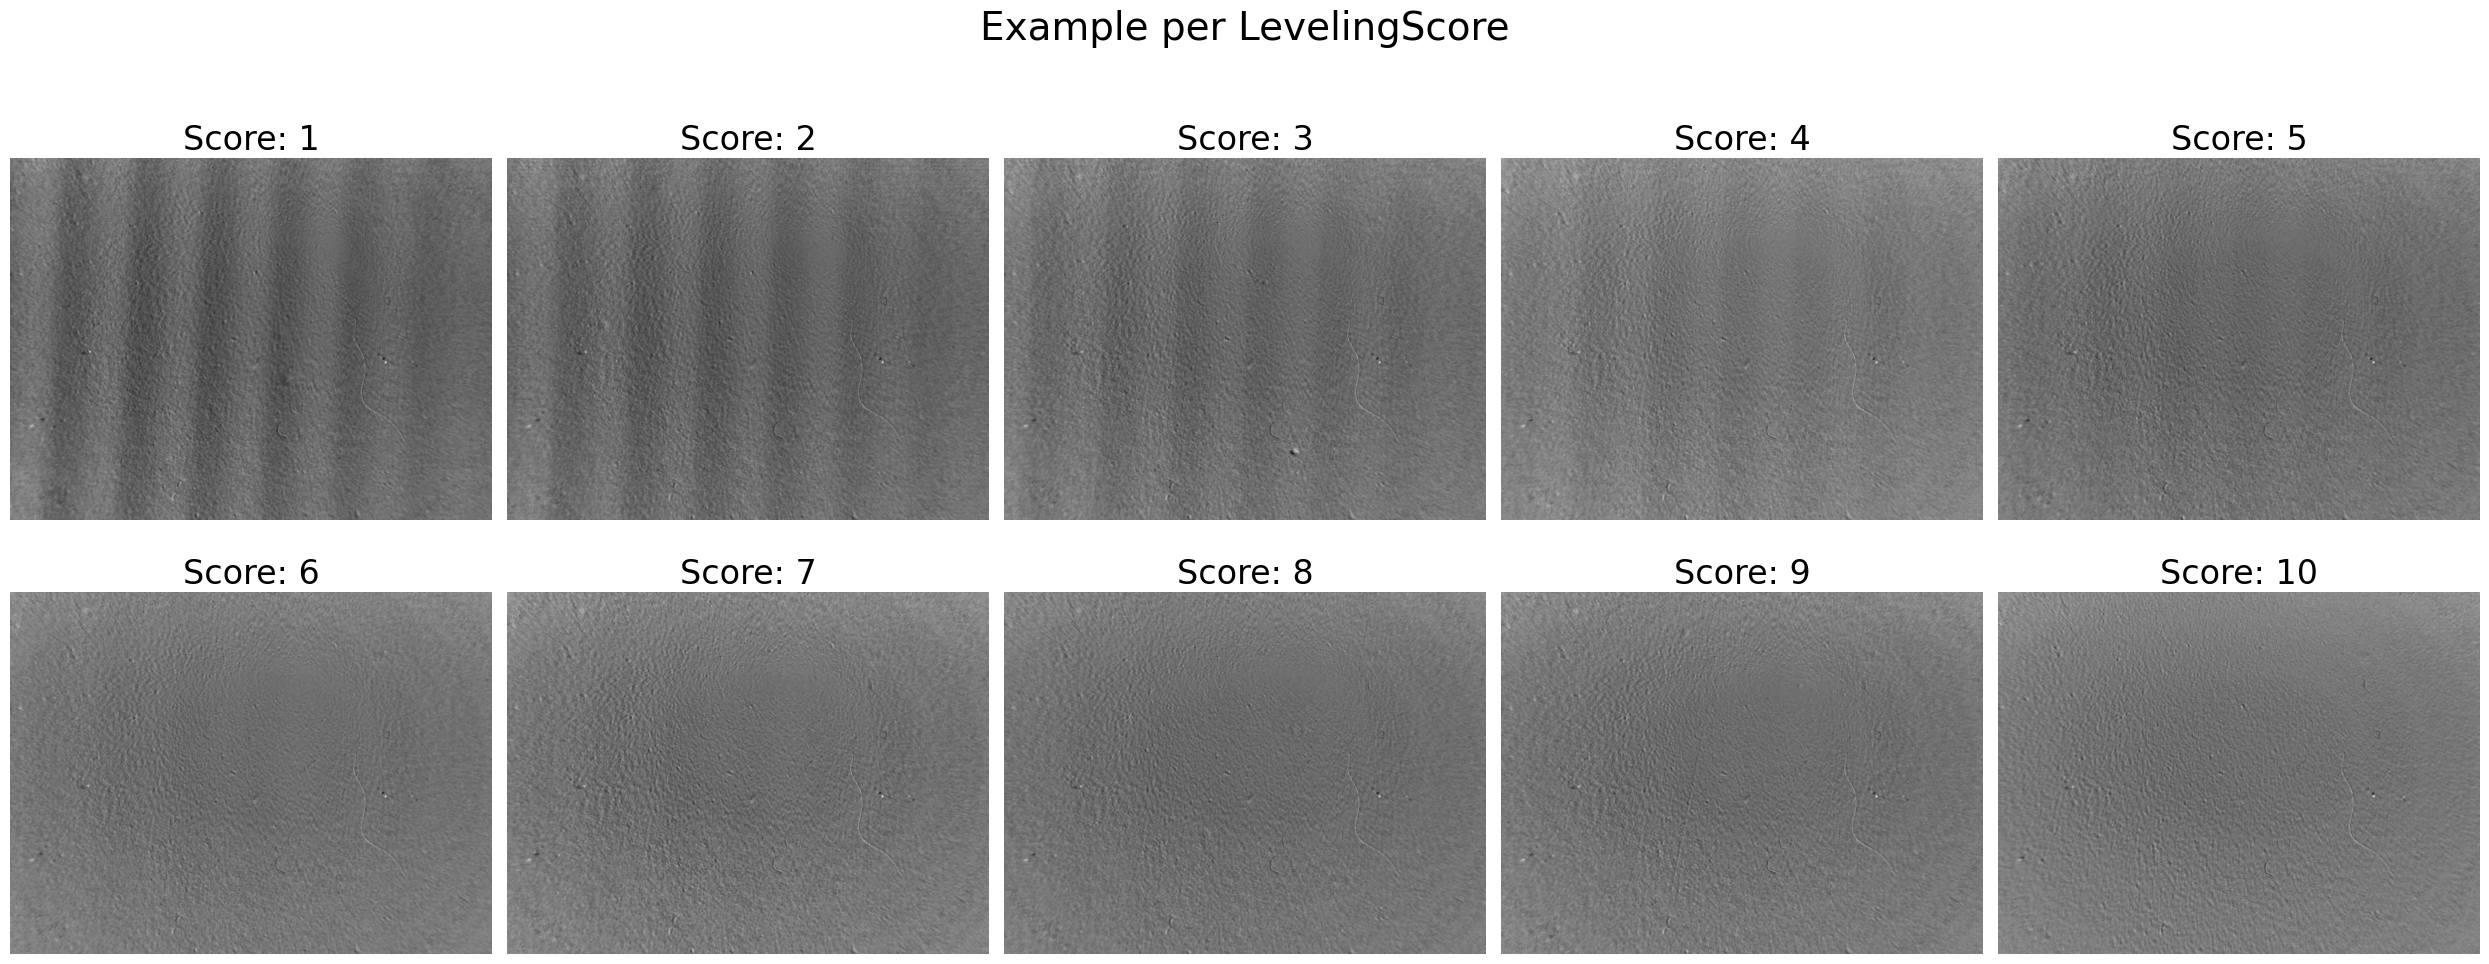

In [7]:
# print out an example of each leveling score for data_standards, all 1 camera type
import matplotlib.pyplot as plt

camera_types = [item["GSCamera"] for item in data_standards if item.get("GSCamera")]
chosen_camera = sorted(set(camera_types))[-1]
print(f"Using camera: {chosen_camera}")

# Collect one example per score 1-10 for the chosen camera.
examples = {}
for item in data_standards:
    if item.get("GSCamera") != chosen_camera:
        continue
    score = item.get("LevelingScore")
    if score in range(1, 11) and score not in examples:
        examples[score] = item

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for idx, score in enumerate(range(1, 11)):
    ax = axes[idx // 5][idx % 5]
    if score in examples:
        ax.imshow(examples[score]["image"], cmap="gray")
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=22, transform=ax.transAxes)
    ax.set_title(f"Score: {score}", fontsize=24)
    ax.axis("off")

plt.suptitle("Example per LevelingScore", fontsize=28, y=1.02)
plt.tight_layout()
plt.show()
